In [2]:
# ============================================================
# MPLUS TIME GRID PIPELINE
# BASELINE EMA + STEPS + HEART RATE
# ============================================================

# TO DO: 
# 1. Add Stress 
# 2. transfer the pipeline from a single notebook in seperate functions (until end of May) 
# and move all in a separate repository

In [1]:
# ============================================================
# IMPORTS AND SETTINGS
# ============================================================

from pyprojroot import here 
from pathlib import Path
import sys
import pandas as pd
import numpy as np

MISSING = -999

# ============================================================
# PATHS
# ============================================================

# .here is located as invisible file in the project root working directory
PROJECT_ROOT = Path(here())

# add project root to sys.path
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

# import local paths from server_config
from server_config import preprocessed_path, redcap_path

# convert server paths to Path objects and set path
passive_path = Path(preprocessed_path) / "backup_passive_recent.feather"
ema_path = Path(preprocessed_path) / "ema_content.pkl"
redcap_path = Path(redcap_path) / "redcap_data.pkl"

# define output path
OUTPUT_DIR = Path(preprocessed_path) / "tessa" / "dsem"

In [2]:
# ============================================================
# LOAD DATA
# ============================================================

df_passive = pd.read_feather(passive_path)
df_ema = pd.read_pickle(ema_path)
df_redcap = pd.read_pickle(redcap_path)


In [3]:
# display all item names
#sorted(df_ema["item"].dropna().unique())

In [4]:
# define affect items
na_cols = ['panas_fear1', 
           'panas_fear2', 
           'panas_guilt1',
           'panas_guilt2', 
           'panas_hostility1', 
           'panas_hostility2',
           'panas_sadness1', 
           'panas_sadness2',
           'panas_loneliness']

pa_cols = ['panas_attentiveness', 
           'panas_joviality1', 
           'panas_joviality2',
           'panas_selfassurance',
           'panas_serenity1', 
           'panas_serenity2']

# note: the items ‘panas_shyness’ and ‘panas_fatigue’ have been excluded because they cannot be clearly assigned to either NA or PA

In [5]:
# ============================================================
# CLEAN EMA
# ============================================================

# 1. keep baseline data only
ema_base = df_ema[df_ema['measurement_burst'] == 0]
# ema_base["measurement_burst"].value_counts() 

# 2. keep relevant columns
df_ema_base = ema_base[['id', 
                        'timestamp_item_completion',
                        'timestamp_beep_completion', 
                        'measurement_burst', 
                        'response', 
                        'item', 
                        'beep_per_person_id',
                        'n_beeps_beeps_completed_per_burst',    # beep count burst (1 - 112)
                        'nr_beep_daily',                        # beep count daily (1 - 8)
                        'n_beeps_completed_per_day',            # sum of beeps completed (per person) within a day
                        'relative_beep_counter'                 # nth beep completed (per person) per burst
                        ]].copy()

# 3. data format 
df_ema_base['id'] = df_ema_base['id'].astype(str)
df_ema_base['response'] = pd.to_numeric(df_ema_base['response'], errors='coerce')

# 4. drop all rows with NaN (prerequisite for pivot)
df_ema_base = df_ema_base.dropna(subset=["id", "beep_per_person_id", "item", "response",])


In [6]:
# 5. keep affect items only                          TO DO: ADD STRESS ITEMS er_intensity, er_control, event_general
affect_items = pa_cols + na_cols

df_ema_affect_long = df_ema_base[
    df_ema_base["item"].isin(affect_items)
].copy()

df_ema_affect_long.shape

# check item counts
#df_ema_affect_long["item"].value_counts()


(395530, 11)

In [7]:
# 6. pivot ema from long to wide format (this creates one row per person beep)
df_ema_wide = (
    df_ema_affect_long
    .pivot_table(
        index=[
            "id",
            "beep_per_person_id",
        ],
        columns="item",
        values="response",
        aggfunc="first"
    )
    .reset_index()
)

df_ema_wide.head()

item,id,beep_per_person_id,panas_attentiveness,panas_fear1,panas_fear2,panas_guilt1,panas_guilt2,panas_hostility1,panas_hostility2,panas_joviality1,panas_joviality2,panas_loneliness,panas_sadness1,panas_sadness2,panas_selfassurance,panas_serenity1,panas_serenity2
0,05kz,20231010_2.0,5.0,4.0,4.0,1.0,3.0,4.0,1.0,3.0,3.0,2.0,4.0,3.0,5.0,4.0,4.0
1,05kz,20231010_3.0,5.0,4.0,4.0,1.0,1.0,3.0,1.0,5.0,5.0,1.0,3.0,2.0,6.0,4.0,5.0
2,05kz,20231010_5.0,6.0,4.0,2.0,1.0,2.0,2.0,1.0,4.0,4.0,1.0,3.0,1.0,6.0,5.0,6.0
3,05kz,20231010_6.0,5.0,1.0,2.0,1.0,1.0,1.0,1.0,5.0,5.0,1.0,1.0,1.0,5.0,6.0,5.0
4,05kz,20231010_7.0,5.0,1.0,2.0,1.0,1.0,1.0,1.0,6.0,6.0,1.0,1.0,1.0,5.0,6.0,6.0


In [8]:
# 7. add beep-level timing and metadata
df_beep_info = (
    df_ema_base
    .groupby(["id", "beep_per_person_id"], as_index=False)
    .agg(
        timestamp_beep_completion=("timestamp_beep_completion", "min"),
        timestamp_item_completion=("timestamp_item_completion", "min"),
        measurement_burst=("measurement_burst", "first"),
        n_beeps_completed_per_burst=("n_beeps_beeps_completed_per_burst", "first"),
        nr_beep_daily=("nr_beep_daily", "first"),
        n_beeps_completed_per_day=("n_beeps_completed_per_day", "first"),
        relative_beep_counter=("relative_beep_counter", "first"),
    )
)

df_ema_wide = df_beep_info.merge(
    df_ema_wide,
    on=["id", "beep_per_person_id"],
    how="left"
)

df_ema_wide.head()

,id,beep_per_person_id,timestamp_beep_completion,timestamp_item_completion,measurement_burst,n_beeps_completed_per_burst,nr_beep_daily,n_beeps_completed_per_day,relative_beep_counter,panas_attentiveness,...,panas_hostility1,panas_hostility2,panas_joviality1,panas_joviality2,panas_loneliness,panas_sadness1,panas_sadness2,panas_selfassurance,panas_serenity1,panas_serenity2
0,05kz,20231010_2.0,2023-10-10 10:10:10.855000+00:00,2023-10-10 10:07:04.089000+00:00,0,48,2.0,5,1,5.0,...,4.0,1.0,3.0,3.0,2.0,4.0,3.0,5.0,4.0,4.0
1,05kz,20231010_3.0,NaT,2023-10-10 11:51:32.262000+00:00,0,48,3.0,5,2,5.0,...,3.0,1.0,5.0,5.0,1.0,3.0,2.0,6.0,4.0,5.0
2,05kz,20231010_5.0,2023-10-10 15:40:40.282000+00:00,2023-10-10 15:35:25.929000+00:00,0,48,5.0,5,3,6.0,...,2.0,1.0,4.0,4.0,1.0,3.0,1.0,6.0,5.0,6.0
3,05kz,20231010_6.0,2023-10-10 17:47:45.036000+00:00,2023-10-10 17:43:45.973000+00:00,0,48,6.0,5,4,5.0,...,1.0,1.0,5.0,5.0,1.0,1.0,1.0,5.0,6.0,5.0
4,05kz,20231010_7.0,2023-10-10 19:38:02.896000+00:00,2023-10-10 19:30:34.913000+00:00,0,48,7.0,5,5,5.0,...,1.0,1.0,6.0,6.0,1.0,1.0,1.0,5.0,6.0,6.0


In [9]:
# 8. create PA and NA scores 
df_ema_wide["pa"] = df_ema_wide[pa_cols].mean(axis=1, skipna=True)
df_ema_wide["na"] = df_ema_wide[na_cols].mean(axis=1, skipna=True)

# descriptive stats
df_ema_wide[["pa", "na"]].describe()


,pa,na
count,26178.000000,26192.000000
mean,3.679307,2.839295
std,1.066087,1.100888
min,1.000000,1.000000
25%,3.000000,2.000000
50%,3.666667,2.777778
75%,4.333333,3.555556
max,7.000000,7.000000


In [10]:
# check missingness
df_ema_wide[["pa", "na"]].isna().mean()

pa    0.000878
na    0.000343
dtype: float64

In [11]:
# ============================================================
# CREATE BASELINE TIME GRID FROM THOSE EMA ROWS
# ============================================================

# rename for readability
df_ema_wide = df_ema_wide.rename(
    columns={
        "timestamp_item_completion": "timestamp"
    }
)

# make sure timestamp is datetime
df_ema_wide["timestamp"] = pd.to_datetime(
    df_ema_wide["timestamp"],
    errors="coerce"
)

# sort by person and time
df_ema_wide = df_ema_wide.sort_values(
    ["id", "timestamp"]
).copy()

# first beep per person
df_ema_wide["t0"] = (df_ema_wide.groupby("id")["timestamp"].transform("first"))

# hours since first beep
df_ema_wide["time_hr"] = ((df_ema_wide["timestamp"] - df_ema_wide["t0"]).dt.total_seconds()/ 3600)

# inspect
df_ema_wide[["id", "timestamp", "time_hr", "pa","na"]].head(10)

# 'time_hr' is the relevant Mplus variable for TINTERVAL = time (2.5)
# if you only want to create a time grid for ema data you can stop here and export it!


,id,timestamp,time_hr,pa,na
0,05kz,2023-10-10 10:07:04.089000+00:00,0.000000,4.000000,2.888889
1,05kz,2023-10-10 11:51:32.262000+00:00,1.741159,5.000000,2.222222
2,05kz,2023-10-10 15:35:25.929000+00:00,5.472733,5.166667,1.888889
3,05kz,2023-10-10 17:43:45.973000+00:00,7.611634,5.166667,1.111111
4,05kz,2023-10-10 19:30:34.913000+00:00,9.391896,5.666667,1.111111
5,05kz,2023-10-11 11:55:26.196000+00:00,25.806141,4.666667,2.444444
6,05kz,2023-10-11 13:43:40.045000+00:00,27.609988,3.333333,3.333333
7,05kz,2023-10-11 17:18:11.717000+00:00,31.185452,2.000000,4.333333
8,05kz,2023-10-11 19:35:16.220000+00:00,33.470036,4.500000,1.888889
9,05kz,2023-10-12 08:10:10.457000+00:00,46.051769,4.000000,3.666667


In [12]:
# no missings - CHECK :)
rows_missing_time = df_ema_wide[
    df_ema_wide["timestamp"].isna()
].copy()

rows_missing_time.head()

,id,beep_per_person_id,timestamp_beep_completion,timestamp,measurement_burst,n_beeps_completed_per_burst,nr_beep_daily,n_beeps_completed_per_day,relative_beep_counter,panas_attentiveness,...,panas_loneliness,panas_sadness1,panas_sadness2,panas_selfassurance,panas_serenity1,panas_serenity2,pa,na,t0,time_hr


In [13]:
# create passive-data windows
# block_end = current EMA timestamp
df_ema_wide["block_end"] = df_ema_wide["timestamp"]

# block_start = previous EMA timestamp
df_ema_wide["block_start"] = (
    df_ema_wide
    .groupby("id")["timestamp"]
    .shift(1)
)

# for first beep, use 2.5 hours before first EMA
df_ema_wide["block_start"] = df_ema_wide["block_start"].fillna(
    df_ema_wide["block_end"] - pd.Timedelta(hours=2.5)
)

# unique block ID for mapping passive data
df_ema_wide["unique_block"] = (
    df_ema_wide["id"].astype(str)
    + "_"
    + df_ema_wide.groupby("id").cumcount().add(1).astype(str)
)

# create grid object for later mapping
df_grid = df_ema_wide[
    [
        "id",
        "unique_block",
        "timestamp",
        "block_start",
        "block_end",
        "time_hr",
        "pa",
        "na",
    ]
].copy()

# inspect
df_grid.head(10)

,id,unique_block,timestamp,block_start,block_end,time_hr,pa,na
0,05kz,05kz_1,2023-10-10 10:07:04.089000+00:00,2023-10-10 07:37:04.089000+00:00,2023-10-10 10:07:04.089000+00:00,0.000000,4.000000,2.888889
1,05kz,05kz_2,2023-10-10 11:51:32.262000+00:00,2023-10-10 10:07:04.089000+00:00,2023-10-10 11:51:32.262000+00:00,1.741159,5.000000,2.222222
2,05kz,05kz_3,2023-10-10 15:35:25.929000+00:00,2023-10-10 11:51:32.262000+00:00,2023-10-10 15:35:25.929000+00:00,5.472733,5.166667,1.888889
3,05kz,05kz_4,2023-10-10 17:43:45.973000+00:00,2023-10-10 15:35:25.929000+00:00,2023-10-10 17:43:45.973000+00:00,7.611634,5.166667,1.111111
4,05kz,05kz_5,2023-10-10 19:30:34.913000+00:00,2023-10-10 17:43:45.973000+00:00,2023-10-10 19:30:34.913000+00:00,9.391896,5.666667,1.111111
5,05kz,05kz_6,2023-10-11 11:55:26.196000+00:00,2023-10-10 19:30:34.913000+00:00,2023-10-11 11:55:26.196000+00:00,25.806141,4.666667,2.444444
6,05kz,05kz_7,2023-10-11 13:43:40.045000+00:00,2023-10-11 11:55:26.196000+00:00,2023-10-11 13:43:40.045000+00:00,27.609988,3.333333,3.333333
7,05kz,05kz_8,2023-10-11 17:18:11.717000+00:00,2023-10-11 13:43:40.045000+00:00,2023-10-11 17:18:11.717000+00:00,31.185452,2.000000,4.333333
8,05kz,05kz_9,2023-10-11 19:35:16.220000+00:00,2023-10-11 17:18:11.717000+00:00,2023-10-11 19:35:16.220000+00:00,33.470036,4.500000,1.888889
9,05kz,05kz_10,2023-10-12 08:10:10.457000+00:00,2023-10-11 19:35:16.220000+00:00,2023-10-12 08:10:10.457000+00:00,46.051769,4.000000,3.666667


This time grid is ready for both:
1. Mplus EMA-only .dat export
2. steps / heart rate mapping

In [14]:
df_passive.head()

,id,for_id,modality,timestamp_start,timestamp_end,local_timestamp_start,local_timestamp_end,time_interval,float_value,boolean_value,start_date,start_hour,timezone_offset,study_version
0,4MLe,FOR11905,Steps,2023-05-17 14:44:00+00:00,2023-05-17 14:45:00+00:00,2023-05-17 15:44:00,2023-05-17 15:45:00,60.0,6.00,<NA>,2023-05-17 00:00:00+00:00,14.0,120.0,Lang
1,4MLe,FOR11905,ActiveBurnedCalories,2023-05-17 14:44:00+00:00,2023-05-17 14:45:00+00:00,2023-05-17 15:44:00,2023-05-17 15:45:00,60.0,0.14,<NA>,2023-05-17 00:00:00+00:00,14.0,120.0,Lang
2,4MLe,FOR11905,CoveredDistance,2023-05-17 14:44:00+00:00,2023-05-17 14:45:00+00:00,2023-05-17 15:44:00,2023-05-17 15:45:00,60.0,4.62,<NA>,2023-05-17 00:00:00+00:00,14.0,120.0,Lang
3,4MLe,FOR11905,HeartRate,2023-05-17 14:58:01+00:00,2023-05-17 14:58:38+00:00,2023-05-17 15:58:01,2023-05-17 15:58:38,37.0,74.00,<NA>,2023-05-17 00:00:00+00:00,14.0,120.0,Lang
4,4MLe,FOR11905,HeartRate,2023-05-17 18:00:55+00:00,NaT,2023-05-17 19:00:55,NaT,NaN,95.00,<NA>,2023-05-17 00:00:00+00:00,18.0,120.0,Lang


In [15]:
# ============================================================
# CLEAN STEPS 
# ============================================================

df_steps = df_passive[df_passive["modality"] == "Steps"].copy()

df_steps["id"] = df_steps["id"].astype(str)

df_steps["timestamp_start"] = pd.to_datetime(
    df_steps["timestamp_start"],
    errors="coerce"
)

df_steps["timestamp_end"] = pd.to_datetime(
    df_steps["timestamp_end"],
    errors="coerce"
)

df_steps["float_value"] = pd.to_numeric(
    df_steps["float_value"],
    errors="coerce"
)

df_steps = df_steps.dropna(
    subset=["id", "timestamp_start", "timestamp_end", "float_value"]
)

df_steps = df_steps[df_steps["float_value"] >= 0]

df_steps["duration_min"] = (
    df_steps["timestamp_end"] - df_steps["timestamp_start"]
).dt.total_seconds() / 60

df_steps = df_steps[df_steps["duration_min"] > 0]

df_steps["steps_per_min"] = df_steps["float_value"] / df_steps["duration_min"]

# in line with Hammelrath et al. (2026): 200 steps per minute as threshold 
df_steps = df_steps[df_steps["steps_per_min"] <= 200] 

df_steps = df_steps.drop(columns=["duration_min", "steps_per_min"])

df_steps.head(100)


,id,for_id,modality,timestamp_start,timestamp_end,local_timestamp_start,local_timestamp_end,time_interval,float_value,boolean_value,start_date,start_hour,timezone_offset,study_version
0,4MLe,FOR11905,Steps,2023-05-17 14:44:00+00:00,2023-05-17 14:45:00+00:00,2023-05-17 15:44:00,2023-05-17 15:45:00,60.0,6.0,<NA>,2023-05-17 00:00:00+00:00,14.0,120.0,Lang
11,4MLe,FOR11905,Steps,2023-05-17 18:01:00+00:00,2023-05-17 18:02:00+00:00,2023-05-17 19:01:00,2023-05-17 19:02:00,60.0,9.0,<NA>,2023-05-17 00:00:00+00:00,18.0,120.0,Lang
39,4MLe,FOR11905,Steps,2023-05-17 18:02:00+00:00,2023-05-17 18:03:00+00:00,2023-05-17 19:02:00,2023-05-17 19:03:00,60.0,29.0,<NA>,2023-05-17 00:00:00+00:00,18.0,120.0,Lang
42,4MLe,FOR11905,Steps,2023-05-17 18:03:00+00:00,2023-05-17 18:04:00+00:00,2023-05-17 19:03:00,2023-05-17 19:04:00,60.0,33.0,<NA>,2023-05-17 00:00:00+00:00,18.0,120.0,Lang
45,4MLe,FOR11905,Steps,2023-05-17 18:04:00+00:00,2023-05-17 18:05:00+00:00,2023-05-17 19:04:00,2023-05-17 19:05:00,60.0,15.0,<NA>,2023-05-17 00:00:00+00:00,18.0,120.0,Lang
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
498,4MLe,FOR11905,Steps,2023-05-18 08:13:00+00:00,2023-05-18 08:14:00+00:00,2023-05-18 09:13:00,2023-05-18 09:14:00,60.0,154.0,<NA>,2023-05-18 00:00:00+00:00,8.0,120.0,Lang
501,4MLe,FOR11905,Steps,2023-05-18 08:14:00+00:00,2023-05-18 08:15:00+00:00,2023-05-18 09:14:00,2023-05-18 09:15:00,60.0,126.0,<NA>,2023-05-18 00:00:00+00:00,8.0,120.0,Lang
504,4MLe,FOR11905,Steps,2023-05-18 08:15:00+00:00,2023-05-18 08:16:00+00:00,2023-05-18 09:15:00,2023-05-18 09:16:00,60.0,174.0,<NA>,2023-05-18 00:00:00+00:00,8.0,120.0,Lang
507,4MLe,FOR11905,Steps,2023-05-18 08:16:00+00:00,2023-05-18 08:17:00+00:00,2023-05-18 09:16:00,2023-05-18 09:17:00,60.0,125.0,<NA>,2023-05-18 00:00:00+00:00,8.0,120.0,Lang


In [16]:
# ============================================================
# CLEAN HR 
# ============================================================

df_hr = df_passive[df_passive["modality"] == "HeartRate"].copy()

df_hr["id"] = df_hr["id"].astype(str)

df_hr["timestamp_start"] = pd.to_datetime(
    df_hr["timestamp_start"],
    errors="coerce"
)

df_hr["float_value"] = pd.to_numeric(
    df_hr["float_value"],
    errors="coerce"
)

df_hr = df_hr.dropna(
    subset=["id", "timestamp_start", "float_value"]
)

# in line with Hammelrath et al. (2026) p. 3
df_hr = df_hr[df_hr["float_value"].between(30, 220)]

df_hr.head()

,id,for_id,modality,timestamp_start,timestamp_end,local_timestamp_start,local_timestamp_end,time_interval,float_value,boolean_value,start_date,start_hour,timezone_offset,study_version
3,4MLe,FOR11905,HeartRate,2023-05-17 14:58:01+00:00,2023-05-17 14:58:38+00:00,2023-05-17 15:58:01,2023-05-17 15:58:38,37.0,74.0,<NA>,2023-05-17 00:00:00+00:00,14.0,120.0,Lang
4,4MLe,FOR11905,HeartRate,2023-05-17 18:00:55+00:00,NaT,2023-05-17 19:00:55,NaT,NaN,95.0,<NA>,2023-05-17 00:00:00+00:00,18.0,120.0,Lang
52,4MLe,FOR11905,HeartRate,2023-05-17 18:08:05+00:00,2023-05-17 18:08:46+00:00,2023-05-17 19:08:05,2023-05-17 19:08:46,41.0,70.0,<NA>,2023-05-17 00:00:00+00:00,18.0,120.0,Lang
53,4MLe,FOR11905,HeartRate,2023-05-17 18:18:19+00:00,2023-05-17 18:19:13+00:00,2023-05-17 19:18:19,2023-05-17 19:19:13,54.0,76.0,<NA>,2023-05-17 00:00:00+00:00,18.0,120.0,Lang
60,4MLe,FOR11905,HeartRate,2023-05-17 18:28:13+00:00,2023-05-17 18:29:02+00:00,2023-05-17 19:28:13,2023-05-17 19:29:02,49.0,69.0,<NA>,2023-05-17 00:00:00+00:00,18.0,120.0,Lang


In [17]:
# ============================================================
# RESTRICT PASSIVE DATA TO BASELINE
# ============================================================

baseline_period = (
    df_grid
    .groupby("id")
    .agg(
        baseline_start=("block_start", "min"),
        baseline_end=("block_end", "max")
    )
    .reset_index()
)

baseline_period.head()

,id,baseline_start,baseline_end
0,05kz,2023-10-10 07:37:04.089000+00:00,2023-10-25 08:19:53.206000+00:00
1,08d6,2024-09-04 09:32:57.422000+00:00,2024-09-18 12:01:51.312000+00:00
2,0Aly,2024-04-08 09:29:48.801000+00:00,2024-04-22 21:32:22.024000+00:00
3,0NEG,2023-10-09 09:34:56.450000+00:00,2023-10-23 19:25:50.535000+00:00
4,0RA8,2024-02-15 12:18:42.200000+00:00,2024-02-28 20:31:38.678000+00:00


In [18]:
# STEPS
df_steps = df_steps.merge(
    baseline_period,
    on="id",
    how="inner"
)

df_steps = df_steps[
    (df_steps["timestamp_start"] <= df_steps["baseline_end"]) &
    (df_steps["timestamp_end"] >= df_steps["baseline_start"])
].copy()

df_steps = df_steps.drop(columns=["baseline_start", "baseline_end"])

df_steps.shape

(1135831, 14)

In [19]:
# HEART RATE 
df_hr = df_hr.merge(
    baseline_period,
    on="id",
    how="inner"
)

df_hr = df_hr[
    (df_hr["timestamp_start"] >= df_hr["baseline_start"]) &
    (df_hr["timestamp_start"] <= df_hr["baseline_end"])
].copy()

df_hr = df_hr.drop(columns=["baseline_start", "baseline_end"])

df_hr.shape


(1110036, 14)

In [20]:
# ============================================================
# MAP PASSIVE DATA INTO BASELINE GRID
# ============================================================

# map steps to ema blocks
joined_steps = df_steps.merge(
    df_grid[
        [
            "id",
            "unique_block",
            "block_start",
            "block_end"
        ]
    ],
    on="id",
    how="inner"
)

joined_steps = joined_steps[
    (joined_steps["timestamp_start"] < joined_steps["block_end"]) &
    (joined_steps["timestamp_end"] > joined_steps["block_start"])
].copy()

joined_steps.shape

(1139866, 17)

In [21]:
# calculate weighted steps

# For each step record and EMA block, take the later start time 
# (the overlap cannot start before the EMA block starts)
joined_steps["overlap_start"] = joined_steps[
    ["timestamp_start", "block_start"]
].max(axis=1)

# For each step record and EMA block, take the earlier end time 
# (the overlap cannot continue after the step record ends)
joined_steps["overlap_end"] = joined_steps[
    ["timestamp_end", "block_end"]
].min(axis=1)

# calculate how many seconds the step record overlaps with the EMA block
joined_steps["overlap_seconds"] = (
    joined_steps["overlap_end"] - joined_steps["overlap_start"]
).dt.total_seconds()

# calculate the total duration of the original step record
joined_steps["sensor_seconds"] = (
    joined_steps["timestamp_end"] - joined_steps["timestamp_start"]
).dt.total_seconds()

# remove invalid step records where the duration is zero or negative
joined_steps = joined_steps[joined_steps["sensor_seconds"] > 0]

# assign only the proportional amount of steps that belongs to the EMA block
# example: overlap_seconds = 1800, sensor_seconds  = 3600, float_value = 600
# weighted_steps = 1800 / 3600 × 600 = 300 -> only 300 of the 600 steps are assigned to this EMA block
joined_steps["weighted_steps"] = (
    joined_steps["overlap_seconds"] / joined_steps["sensor_seconds"]
) * joined_steps["float_value"]

# sum all weighted step records within each EMA block
steps_summary = (
    joined_steps
    .groupby("unique_block")["weighted_steps"]
    .sum()
    .reset_index(name="steps")
)

steps_summary.head()

,unique_block,steps
0,05kz_1,120.00000
1,05kz_10,99.56855
2,05kz_11,599.43145
3,05kz_12,1120.56560
4,05kz_13,13.43440


In [22]:
# merge onto grid
df_grid = df_grid.merge(
    steps_summary,
    on="unique_block",
    how="left"
)

df_grid.head()

,id,unique_block,timestamp,block_start,block_end,time_hr,pa,na,steps
0,05kz,05kz_1,2023-10-10 10:07:04.089000+00:00,2023-10-10 07:37:04.089000+00:00,2023-10-10 10:07:04.089000+00:00,0.000000,4.000000,2.888889,120.0
1,05kz,05kz_2,2023-10-10 11:51:32.262000+00:00,2023-10-10 10:07:04.089000+00:00,2023-10-10 11:51:32.262000+00:00,1.741159,5.000000,2.222222,979.0
2,05kz,05kz_3,2023-10-10 15:35:25.929000+00:00,2023-10-10 11:51:32.262000+00:00,2023-10-10 15:35:25.929000+00:00,5.472733,5.166667,1.888889,931.0
3,05kz,05kz_4,2023-10-10 17:43:45.973000+00:00,2023-10-10 15:35:25.929000+00:00,2023-10-10 17:43:45.973000+00:00,7.611634,5.166667,1.111111,297.0
4,05kz,05kz_5,2023-10-10 19:30:34.913000+00:00,2023-10-10 17:43:45.973000+00:00,2023-10-10 19:30:34.913000+00:00,9.391896,5.666667,1.111111,163.0


<Axes: >

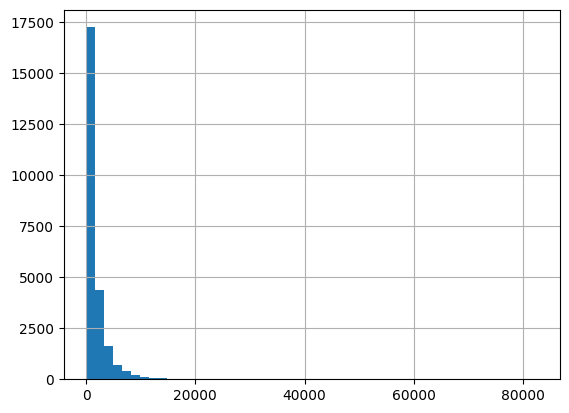

In [23]:
# steps are highly skewed
df_grid["steps"].hist(bins=50)

# if it looks strongly skewed use log transformation to reduce skewness and stabilize estimation
#np.log1p()

#raw steps: absolute physical activity volume
#log-transformed steps: relative/intensity-scaled activity variation 

In [24]:
# map heart rate to ema blocks
joined_hr = df_hr.merge(
    df_grid[
        [
            "id",
            "unique_block",
            "block_start",
            "block_end"
        ]
    ],
    on="id",
    how="inner"
)

joined_hr = joined_hr[
    (joined_hr["timestamp_start"] >= joined_hr["block_start"]) &
    (joined_hr["timestamp_start"] < joined_hr["block_end"])
].copy()

joined_hr.shape


(1110036, 17)

In [25]:
# aggregate HR
hr_summary = (
    joined_hr
    .groupby("unique_block")["float_value"]
    .agg(
        hr_mean="mean",
        hr_median="median",
        hr_sd="std",   
        hr_n="count"
    )
    .reset_index()
)

hr_summary.head()

,unique_block,hr_mean,hr_median,hr_sd,hr_n
0,05kz_1,62.333333,61.0,17.039171,3
1,05kz_10,56.402778,54.5,6.440759,72
2,05kz_11,74.666667,79.5,9.223159,6
3,05kz_12,73.750000,66.0,17.854571,8
4,05kz_13,62.666667,66.0,11.758685,6


In [26]:
# merge into grid
df_grid = df_grid.merge(
    hr_summary,
    on="unique_block",
    how="left"
)

df_grid.head()

,id,unique_block,timestamp,block_start,block_end,time_hr,pa,na,steps,hr_mean,hr_median,hr_sd,hr_n
0,05kz,05kz_1,2023-10-10 10:07:04.089000+00:00,2023-10-10 07:37:04.089000+00:00,2023-10-10 10:07:04.089000+00:00,0.000000,4.000000,2.888889,120.0,62.333333,61.0,17.039171,3.0
1,05kz,05kz_2,2023-10-10 11:51:32.262000+00:00,2023-10-10 10:07:04.089000+00:00,2023-10-10 11:51:32.262000+00:00,1.741159,5.000000,2.222222,979.0,64.400000,62.0,5.272571,5.0
2,05kz,05kz_3,2023-10-10 15:35:25.929000+00:00,2023-10-10 11:51:32.262000+00:00,2023-10-10 15:35:25.929000+00:00,5.472733,5.166667,1.888889,931.0,69.687500,70.0,5.712195,16.0
3,05kz,05kz_4,2023-10-10 17:43:45.973000+00:00,2023-10-10 15:35:25.929000+00:00,2023-10-10 17:43:45.973000+00:00,7.611634,5.166667,1.111111,297.0,62.090909,58.0,7.854356,11.0
4,05kz,05kz_5,2023-10-10 19:30:34.913000+00:00,2023-10-10 17:43:45.973000+00:00,2023-10-10 19:30:34.913000+00:00,9.391896,5.666667,1.111111,163.0,72.636364,72.0,4.031693,11.0


In [27]:
# check final missingness
df_grid[["pa", "na", "steps", "hr_mean"]].isna().mean()

pa         0.000878
na         0.000343
steps      0.048777
hr_mean    0.043090
dtype: float64

In [28]:
# check distributions
df_grid[["pa", "na", "steps", "hr_mean"]].describe()

,pa,na,steps,hr_mean
count,26178.000000,26192.000000,24923.000000,25072.000000
mean,3.679307,2.839295,1623.636738,77.347108
std,1.066087,1.100888,2684.441369,13.984041
min,1.000000,1.000000,0.868700,41.500000
25%,3.000000,2.000000,232.000000,68.142857
50%,3.666667,2.777778,760.000000,75.317957
75%,4.333333,3.555556,2032.000000,84.230769
max,7.000000,7.000000,82575.983540,176.000000


In [29]:
# optional: log-transform steps (recommended for modeling?) 
df_grid["steps_log"] = np.log1p(df_grid["steps"])

df_grid[["steps", "steps_log"]].describe()

df_grid.head()

,id,unique_block,timestamp,block_start,block_end,time_hr,pa,na,steps,hr_mean,hr_median,hr_sd,hr_n,steps_log
0,05kz,05kz_1,2023-10-10 10:07:04.089000+00:00,2023-10-10 07:37:04.089000+00:00,2023-10-10 10:07:04.089000+00:00,0.000000,4.000000,2.888889,120.0,62.333333,61.0,17.039171,3.0,4.795791
1,05kz,05kz_2,2023-10-10 11:51:32.262000+00:00,2023-10-10 10:07:04.089000+00:00,2023-10-10 11:51:32.262000+00:00,1.741159,5.000000,2.222222,979.0,64.400000,62.0,5.272571,5.0,6.887553
2,05kz,05kz_3,2023-10-10 15:35:25.929000+00:00,2023-10-10 11:51:32.262000+00:00,2023-10-10 15:35:25.929000+00:00,5.472733,5.166667,1.888889,931.0,69.687500,70.0,5.712195,16.0,6.837333
3,05kz,05kz_4,2023-10-10 17:43:45.973000+00:00,2023-10-10 15:35:25.929000+00:00,2023-10-10 17:43:45.973000+00:00,7.611634,5.166667,1.111111,297.0,62.090909,58.0,7.854356,11.0,5.697093
4,05kz,05kz_5,2023-10-10 19:30:34.913000+00:00,2023-10-10 17:43:45.973000+00:00,2023-10-10 19:30:34.913000+00:00,9.391896,5.666667,1.111111,163.0,72.636364,72.0,4.031693,11.0,5.099866


In [32]:
# ============================================================
# CREATE FINAL MPLUS DATASET
# ============================================================

mplus_affect_steps_hr = df_grid[
    [
        "id",
        "time_hr",
        "pa",
        "na",
        "steps",
        "steps_log",
        "hr_mean",
        "hr_median",
        "hr_sd"
    ]
].copy()


# replace infinite values
mplus_affect_steps_hr = mplus_affect_steps_hr.replace(
    [np.inf, -np.inf],
    np.nan
)

# replace missing values for Mplus (cannot handle NaN, only -999)
mplus_affect_steps_hr = mplus_affect_steps_hr.fillna(MISSING)

# important for later modeling: ensure appropriate sorting (in ascending order) -> observations must be ordered
mplus_affect_steps_hr = (mplus_affect_steps_hr.sort_values(["id", "time_hr"]).reset_index(drop=True))

# sanity check
mplus_affect_steps_hr.head(20)

,id,time_hr,pa,na,steps,steps_log,hr_mean,hr_median,hr_sd
0,05kz,0.000000,4.000000,2.888889,120.00000,4.795791,62.333333,61.0,17.039171
1,05kz,1.741159,5.000000,2.222222,979.00000,6.887553,64.400000,62.0,5.272571
2,05kz,5.472733,5.166667,1.888889,931.00000,6.837333,69.687500,70.0,5.712195
3,05kz,7.611634,5.166667,1.111111,297.00000,5.697093,62.090909,58.0,7.854356
4,05kz,9.391896,5.666667,1.111111,163.00000,5.099866,72.636364,72.0,4.031693
5,05kz,25.806141,4.666667,2.444444,2694.00000,7.899153,60.202899,57.0,9.738613
6,05kz,27.609988,3.333333,3.333333,270.00000,5.602119,68.285714,71.0,12.297890
7,05kz,31.185452,2.000000,4.333333,2268.00000,7.727094,69.588235,65.0,17.660191
8,05kz,33.470036,4.500000,1.888889,-999.00000,-999.000000,66.692308,67.0,3.794395
9,05kz,46.051769,4.000000,3.666667,99.56855,4.610840,56.402778,54.5,6.440759


In [33]:
#stable numeric ids after sorting by original id
mplus_affect_steps_hr["id_num"] = (
    pd.factorize(mplus_affect_steps_hr["id"], sort=True)[0] + 1
)

# optional: save mapping for later merge-back
id_map = (mplus_affect_steps_hr[["id", "id_num"]]
          .drop_duplicates()
          .sort_values("id_num"))
id_map.to_csv(OUTPUT_DIR / "id_mapping.csv", index=False)


mplus_affect_steps_hr.head()

,id,time_hr,pa,na,steps,steps_log,hr_mean,hr_median,hr_sd,id_num
0,05kz,0.000000,4.000000,2.888889,120.0,4.795791,62.333333,61.0,17.039171,1
1,05kz,1.741159,5.000000,2.222222,979.0,6.887553,64.400000,62.0,5.272571,1
2,05kz,5.472733,5.166667,1.888889,931.0,6.837333,69.687500,70.0,5.712195,1
3,05kz,7.611634,5.166667,1.111111,297.0,5.697093,62.090909,58.0,7.854356,1
4,05kz,9.391896,5.666667,1.111111,163.0,5.099866,72.636364,72.0,4.031693,1


In [34]:
# save .csv file (with headers) / good for inspection
mplus_affect_steps_hr.to_csv(
    OUTPUT_DIR / "mplus_affect_steps_hr.csv",
    index=False
)

# save .dat file for Mplus (space-delimited, header-less)
# IMPORTANT: id_num must be the FIRST column because your Mplus NAMES order assumes that
mplus_cols = [
    "id_num", "time_hr", "pa", "na", "steps_log", "steps", "hr_mean", "hr_median", "hr_sd"
]

# save .dat file for Mplus (tab-delimited, header-less: suitable for Mplus)
mplus_affect_steps_hr[mplus_cols].to_csv(
    OUTPUT_DIR / "mplus_affect_steps_hr.dat",
    sep=" ",
    header=False,
    index=False
)

In [74]:
# example reponse distribution
#df_ema_wide['panas_attentiveness'].value_counts().sort_index()